# ReAct Agentic RAG — Code Flow

A plain-English walkthrough of the system's structure, top to bottom.

---

## Big Picture

The system answers questions by combining two knowledge sources — a local document database and Wikipedia — using an AI agent that reasons step by step before giving a final answer. Everything is wired together using LangGraph, which acts as the backbone that controls the flow between steps.

---

## Step 1 — Setup & Configuration

The system starts by loading environment variables (specifically the OpenAI API key) and initializing the large language model (GPT-4o) that will power all reasoning and answer generation throughout the pipeline.

---

## Step 2 — Document Loading & Chunking

Two AI/ML blog posts are fetched from the web. Because these articles are long, they are broken into smaller overlapping pieces called chunks. The chunking is done carefully — it tries to split at natural boundaries like paragraph breaks first, only falling back to sentence or word boundaries if necessary. Overlapping ensures that sentences near a split point appear in both adjacent chunks, so no context is lost.

---

## Step 3 — Vector Store (FAISS)

Each chunk is converted into a numerical representation (an embedding) that captures its meaning. All embeddings are stored in a FAISS vector database on disk. If the database already exists from a previous run, it is loaded directly — avoiding the cost and time of re-embedding. A retriever is created on top of FAISS using MMR (Maximal Marginal Relevance), which returns results that are both relevant to the query and diverse from each other, preventing near-duplicate chunks from all being returned at once.

---

## Step 4 — Tools

Two tools are defined for the agent to use:

**Tool 1 — Vector Store Retriever**
Searches the local FAISS database for chunks relevant to the query. Any chunk scoring below a minimum relevance threshold is filtered out, so the agent never receives low-quality context. Results are returned with source URLs and relevance scores.

**Tool 2 — Wikipedia Search**
Queries Wikipedia and returns summaries from the top matching articles. This is the fallback — used only when the local vector store doesn't have sufficient information.

The agent is always instructed to try the vector store first and only use Wikipedia as a backup.

---

## Step 5 — ReAct Agent

A ReAct agent is created using `create_agent` (the modern LangChain API). It is given the LLM, the two tools, and a system prompt that defines its behavior. The system prompt instructs it to always use a tool before answering, cite which tool and chunk it used, and never fabricate information. The agent internally runs a loop — Thought → Tool Call → Observation → Thought → … — until it produces a final answer with no further tool calls needed.

---

## Step 6 — State Schema

A shared state object is defined to carry information between steps in the graph. It holds three things: the full message history (which grows as the agent reasons and calls tools), the original user question (preserved unchanged throughout), and the final answer (filled in at the end). LangGraph's `add_messages` reducer automatically appends new messages to the history rather than overwriting it.

---

## Step 7 — Graph Nodes

Two functions are defined, each representing a node (a step) in the LangGraph workflow:

**Node 1 — `run_agent`**
Invokes the ReAct agent with the current message history. The agent runs its full reasoning loop internally and returns the complete message trace. The last message in that trace is extracted as the final answer and stored in state.

**Node 2 — `format_output`**
A lightweight post-processing step that finalizes the output. This is where logging, citation reformatting, or output validation logic would live.

---

## Step 8 — LangGraph Workflow Assembly

The two nodes are connected into a linear graph:

```
START → run_agent → format_output → END
```

LangGraph compiles this into an executable pipeline. The compiled graph is what actually gets invoked when a question is asked.

---

## Step 9 — Public Interface (`ask`)

A single `ask(question)` function wraps the entire pipeline. It takes a plain string question, packages it into the initial state, runs it through the compiled graph, prints the final answer, and returns it. This is the only function a caller needs to know about.

---

## Step 10 — Entry Point

When the script is run directly, three sample questions are sent through the pipeline one by one, each printing its answer to the console.

---

## End-to-End Flow Summary

```
User Question
     ↓
Package into AgentState (messages + question)
     ↓
LangGraph: START
     ↓
Node 1 — run_agent
     ↓
  ReAct Loop (internal):
  ┌─────────────────────────────────────┐
  │  LLM thinks about the question      │
  │         ↓                           │
  │  Calls Tool 1 (Vector Store)        │
  │         ↓                           │
  │  Receives chunks + scores           │
  │         ↓                           │
  │  If insufficient → calls Tool 2     │
  │         (Wikipedia)                 │
  │         ↓                           │
  │  LLM generates cited answer         │
  └─────────────────────────────────────┘
     ↓
Node 2 — format_output
     ↓
LangGraph: END
     ↓
Final Answer returned to user
```

In [1]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.documents import Document
from typing import List
from pydantic import BaseModel
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END
from langgraph.graph import StateGraph
from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph.message import add_messages

# --- Configuration ---
load_dotenv()

# init_chat_model will read OPENAI_API_KEY from the environment automatically;
# no need to re-assign it via os.environ.
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
llm = init_chat_model("openai:gpt-4o")

c:\Users\Parth\Downloads\Agentic_Rag\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
# -----------------------------------------------
# 1. Document Preprocessing
# -----------------------------------------------
# Load web pages, split them into chunks, and index
# them into a FAISS vector store for similarity search.

URLS = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/",
]

# Load raw HTML content from each URL
docs = []
for url in URLS:
    docs.extend(WebBaseLoader(url).load())

# Split documents into overlapping chunks to preserve context across boundaries
# Use semantic-aware separators so splits happen at natural boundaries
# (sections → paragraphs → sentences → words) before falling back to characters.
# chunk_size=800 gives enough context per chunk for technical blog posts.
# chunk_overlap=100 prevents key sentences from being lost at chunk edges.
splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n\n", "\n\n", "\n", ". ", " ", ""],
    chunk_size=800,
    chunk_overlap=100,
    length_function=len,
    add_start_index=True,   # stores char offset in metadata — useful for debugging
)
split_docs = splitter.split_documents(docs)


In [3]:
# ─────────────────────────────────────────────
# 2. Build FAISS Vector Store from Web Docs
# ─────────────────────────────────────────────
FAISS_INDEX_PATH = "faiss_index"

embedding = OpenAIEmbeddings(
    model="text-embedding-3-small",  # cheaper + faster than ada-002, often better
    chunk_size=200,                  # batch size for embedding API calls — avoids rate limits
)

# Load from disk if it already exists, otherwise build and save.
# This avoids re-embedding on every run — critical for cost and speed.
if os.path.exists(FAISS_INDEX_PATH):
    vectorstore = FAISS.load_local(
        FAISS_INDEX_PATH,
        embeddings=embedding,
        allow_dangerous_deserialization=True,  # required by LangChain for local loads
    )
    print("Loaded FAISS index from disk.")
else:
    vectorstore = FAISS.from_documents(split_docs, embedding)
    vectorstore.save_local(FAISS_INDEX_PATH)
    print(f"Built and saved FAISS index ({len(split_docs)} chunks).")

# Use MMR (Maximal Marginal Relevance) instead of plain similarity search.
# MMR balances relevance with diversity — prevents 5 near-duplicate chunks
# from all being returned for the same query.
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k": 5,           # number of chunks to return
        "fetch_k": 20,    # candidate pool MMR selects from — larger = more diverse results
        "lambda_mult": 0.6,  # 0=max diversity, 1=max relevance; 0.6 is a good default
    },
)

Loaded FAISS index from disk.


In [4]:

# ─────────────────────────────────────────────
# 3. Define Tools
# ─────────────────────────────────────────────

@tool
def retrieve_from_vectorstore(query: str) -> str:
    """
    Search the local FAISS vector store for relevant information.
    Use this tool first before falling back to Wikipedia.
    Returns the top matching document chunks with their sources.
    """
    docs_with_scores = vectorstore.similarity_search_with_relevance_scores(query, k=5)

    # Filter chunks below relevance threshold
    filtered = [(doc, score) for doc, score in docs_with_scores if score >= 0.30]

    if not filtered:
        return "No relevant documents found in the local vector store."

    results = []
    for i, (doc, score) in enumerate(filtered, 1):
        source = doc.metadata.get("source", "Unknown")
        results.append(
            f"[Chunk {i}] Score: {score:.2f} | Source: {source}\n{doc.page_content}"
        )

    return "\n\n---\n\n".join(results)


# Wikipedia tool — used as fallback when local docs are insufficient
wikipedia_tool = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper(
        top_k_results=3,        # return top 3 Wikipedia articles
        doc_content_chars_max=2000,  # cap each article at 2000 chars
    )
)

# Bundle all tools the ReAct agent can invoke
TOOLS = [retrieve_from_vectorstore, wikipedia_tool]

[Agent] Initialized with create_agent (new API).


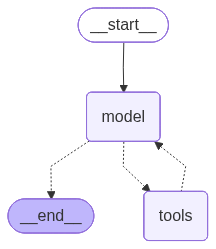

In [5]:
from langchain.agents import create_agent 
# In 2026, 'create_agent' often replaces 'create_react_agent' as a unified function
from langchain_classic.agents import AgentExecutor
from langchain_core.prompts import PromptTemplate
# ─────────────────────────────────────────────
# 4. ReAct Agent (prebuilt LangGraph node)
# ─────────────────────────────────────────────

SYSTEM_PROMPT = """You are a precise research assistant with access to two tools:

1. retrieve_from_vectorstore — searches a local knowledge base of AI/ML blog posts.
   ALWAYS use this tool FIRST for questions about LLM agents, diffusion models, or similar topics.

2. wikipedia — searches Wikipedia for general or background knowledge.
   Use this as a FALLBACK only if the vector store returns no relevant results,
   or to supplement with broader context.

Rules:
- Always invoke at least one tool before answering.
- Cite which tool(s) and chunk numbers you used in your answer.
- If neither tool has relevant information, clearly state that.
- Never fabricate or guess information not present in the tool outputs.
- Be concise and structured in your responses."""

agent = create_agent(
    model=llm,                  # LLM instance (or model string like "openai:gpt-4o")
    tools=TOOLS,                # list of @tool-decorated functions
    system_prompt=SYSTEM_PROMPT,# plain string — no PromptTemplate required
    name="rag_wikipedia_agent", # node name when used as a subgraph
)

print("[Agent] Initialized with create_agent (new API).")



# ─────────────────────────────────────────────
# 5. LangGraph State
# ─────────────────────────────────────────────

class AgentState(TypedDict):
    """
    State passed between nodes in the LangGraph workflow.

    messages: full conversation history (auto-merged by add_messages reducer).
    question: original user question, preserved throughout the graph.
    answer:   final answer extracted from the ReAct agent's last message.
    """
    messages: Annotated[Sequence[BaseMessage], add_messages]
    question: str
    answer: str
agent

In [10]:
# ─────────────────────────────────────────────
# 6. Graph Nodes
# ─────────────────────────────────────────────
def run_agent(state: AgentState) -> AgentState:
    """
    Node: Invoke the create_agent graph.

    create_agent returns a compiled LangGraph graph, so we invoke it
    with {"messages": [...]} just like any other LangGraph graph.
    The agent internally handles the full ReAct loop:
        LLM → tool call → observation → LLM → ... → final answer
    """
    print(f"\n[Agent Node] Question: {state['question']}")

    # create_agent graph takes {"messages": [...]} as input
    result = agent.invoke({"messages": state["messages"]})

    # The last message is always the agent's final text response
    final_message = result["messages"][-1]
    answer_text = (
        final_message.content
        if hasattr(final_message, "content")
        else str(final_message)
    )

    print(f"[Agent Node] Completed. Answer length: {len(answer_text)} chars.")
    return {
        "messages": result["messages"],
        "question": state["question"],
        "answer": answer_text,
    }

def format_output(state: AgentState) -> AgentState:
    """
    Node: Rich diagnostic display of the full agent run.

    Reads from AgentState to surface:
      - The original question        (from state["question"])
      - Every step the agent took    (from state["messages"])
          HumanMessage  → the user's question
          AIMessage     → the agent's reasoning and/or tool calls
          ToolMessage   → the raw output returned by each tool
      - A tool usage summary: which tools were called and how many times
      - Pipeline metadata: message counts, total tool calls
      - The clean final answer       (from state["answer"])

    Nothing in state is modified — this node is purely read-only.
    """
    DIVIDER   = "═" * 60
    THIN_LINE = "─" * 60
    STEP_ICONS = {
        "HumanMessage": "❓ USER",
        "AIMessage":    "🤖 AGENT",
        "ToolMessage":  "🔧 TOOL RESULT",
    }

    print(f"\n{DIVIDER}")
    print("📋  AGENT RUN SUMMARY")
    print(DIVIDER)

    # ── 1. Original question (read directly from state["question"]) ───
    print(f"\n🎯  Question : {state['question']}")

    # ── 2. Full message trace from state["messages"] ──────────────────
    # state["messages"] holds the complete history built up across the
    # entire ReAct loop — every thought, tool call, and result is here.
    print(f"\n{THIN_LINE}")
    print("📨  Message Trace  (every step the agent took)")
    print(THIN_LINE)

    tool_call_counts: dict = {}  # { tool_name: call_count }

    for i, message in enumerate(state["messages"], 1):
        msg_type = type(message).__name__
        icon     = STEP_ICONS.get(msg_type, "💬 MESSAGE")
        print(f"\n  [{i}] {icon}")

        if msg_type == "AIMessage":
            # AIMessage with tool_calls = agent is mid-loop, deciding which tool to use
            if hasattr(message, "tool_calls") and message.tool_calls:
                for tc in message.tool_calls:
                    tool_name = tc.get("name", "unknown_tool")
                    tool_args = tc.get("args", {})
                    tool_call_counts[tool_name] = tool_call_counts.get(tool_name, 0) + 1
                    print(f"       ↳ Called tool : {tool_name}")
                    print(f"         With args  : {tool_args}")
            elif message.content:
                # AIMessage with content but no tool_calls = final answer
                preview = message.content[:300]
                suffix  = "…" if len(message.content) > 300 else ""
                print(f"       Content : {preview}{suffix}")

        elif msg_type == "ToolMessage":
            # ToolMessage = raw string returned by the tool back to the agent
            tool_name = getattr(message, "name", "unknown_tool")
            content   = message.content or "(empty)"
            preview   = content[:300]
            suffix    = "…" if len(content) > 300 else ""
            print(f"       Tool   : {tool_name}")
            print(f"       Output : {preview}{suffix}")

        else:
            # HumanMessage = the original user question
            print(f"       Content : {message.content}")

    # ── 3. Tool usage summary ─────────────────────────────────────────
    print(f"\n{THIN_LINE}")
    print("🛠️   Tool Usage Summary")
    print(THIN_LINE)
    if tool_call_counts:
        for tool_name, count in tool_call_counts.items():
            label = "call" if count == 1 else "calls"
            print(f"   • {tool_name:<35} {count} {label}")
    else:
        print("   No tools were called.")

    # ── 4. Pipeline metadata from state ──────────────────────────────
    print(f"\n{THIN_LINE}")
    print("📊  Pipeline Metadata")
    print(THIN_LINE)
    total_msgs   = len(state["messages"])
    tool_msgs    = sum(1 for m in state["messages"] if type(m).__name__ == "ToolMessage")
    agent_msgs   = sum(1 for m in state["messages"] if type(m).__name__ == "AIMessage")
    total_calls  = sum(tool_call_counts.values())
    print(f"   Total messages in state : {total_msgs}")
    print(f"   Agent thinking steps    : {agent_msgs}")
    print(f"   Tool result messages    : {tool_msgs}")
    print(f"   Total tool calls made   : {total_calls}")

    # ── 5. Final answer from state["answer"] ─────────────────────────
    print(f"\n{DIVIDER}")
    print("✅  FINAL ANSWER")
    print(DIVIDER)
    print(state["answer"])
    print(f"{DIVIDER}\n")

    return state

[Graph] Compiled successfully.


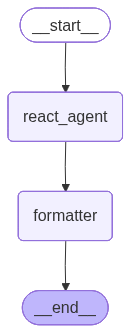

In [11]:
# ─────────────────────────────────────────────
# 7. Build the LangGraph Workflow
# ─────────────────────────────────────────────

builder = StateGraph(AgentState)

# Register nodes
builder.add_node("react_agent", run_agent)
builder.add_node("formatter", format_output)

# Define flow: START → react_agent → formatter → END
builder.set_entry_point("react_agent")
builder.add_edge("react_agent", "formatter")
builder.add_edge("formatter", END)

graph = builder.compile()
print("[Graph] Compiled successfully.")
graph

In [12]:

# ─────────────────────────────────────────────
# 8. Run the Pipeline
# ─────────────────────────────────────────────

def ask(question: str) -> str:
    """
    Public interface to run the Agentic RAG pipeline.

    The ReAct agent will:
      1. Search the local FAISS vector store first.
      2. Fall back to Wikipedia if local results are insufficient.
      3. Return a cited, grounded answer.

    Args:
        question: The user's natural language question.

    Returns:
        The agent's final answer as a string.
    """
    initial_state: AgentState = {
        "messages": [HumanMessage(content=question)],
        "question": question,
        "answer": "",
    }

    final_state = graph.invoke(initial_state)

    print("\n" + "═" * 60)
    print("✅ FINAL ANSWER")
    print("═" * 60)
    print(final_state["answer"])
    print("═" * 60 + "\n")

    return final_state["answer"]

In [13]:
# ─────────────────────────────────────────────
# 9. Entry Point
# ─────────────────────────────────────────────

if __name__ == "__main__":
    questions = [
        "What is the agent loop in autonomous LLM agents?",
        "How does self-reflection work in agents like Reflexion?",
        "What is diffusion model and how is it used in video generation?",
    ]

    for q in questions:
        print(f"\n{'─' * 60}")
        print(f"❓ QUESTION: {q}")
        ask(q)


────────────────────────────────────────────────────────────
❓ QUESTION: What is the agent loop in autonomous LLM agents?

[Agent Node] Question: What is the agent loop in autonomous LLM agents?
[Agent Node] Completed. Answer length: 1295 chars.

════════════════════════════════════════════════════════════
📋  AGENT RUN SUMMARY
════════════════════════════════════════════════════════════

🎯  Question : What is the agent loop in autonomous LLM agents?

────────────────────────────────────────────────────────────
📨  Message Trace  (every step the agent took)
────────────────────────────────────────────────────────────

  [1] ❓ USER
       Content : What is the agent loop in autonomous LLM agents?

  [2] 🤖 AGENT
       ↳ Called tool : retrieve_from_vectorstore
         With args  : {'query': 'agent loop in autonomous LLM agents'}

  [3] 🔧 TOOL RESULT
       Tool   : retrieve_from_vectorstore
       Output : [Chunk 1] Score: 0.60 | Source: https://lilianweng.github.io/posts/2023-06-23-agen